In [2]:
# =========================================================
# NEWS CLASSIFICATION BASELINE + VISUALIZATION
# TF-IDF + LOGISTIC REGRESSION
# =========================================================

# =========================================================
# 1. IMPORT LIBRARIES
# =========================================================

import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


In [3]:
# =========================================================
# 2. LOAD DATA
# =========================================================

DATASET_PATH = "/content/drive/MyDrive/nlp_project/data/raw"

texts = []
labels = []

for label_name in os.listdir(DATASET_PATH):
    folder_path = os.path.join(DATASET_PATH, label_name)

    if os.path.isdir(folder_path):
        for file_name in os.listdir(folder_path):
            if file_name.endswith(".txt"):
                file_path = os.path.join(folder_path, file_name)

                try:
                    with open(file_path, "r", encoding="utf-8") as f:
                        texts.append(f.read())
                        labels.append(label_name)
                except Exception as e:
                    print(f"Error reading {file_name}: {e}")

df = pd.DataFrame({"text": texts, "label": labels})

In [4]:
# =========================================================
# 3. PREPROCESSING
# =========================================================

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["text"] = df["text"].apply(preprocess_text)


In [5]:
# =========================================================
# 4. LABEL ENCODING
# =========================================================

label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["label"])

In [10]:
# =========================================================
# 5. TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    df["text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

In [11]:
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
# =========================================================
# 6. DEFINE MODELS
# =========================================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": LinearSVC(),
    "Naive Bayes": MultinomialNB()
}

results = {}
conf_matrices = {}

In [12]:
# =========================================================
# 7. TRAIN & EVALUATE
# =========================================================

for name, clf in models.items():

    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
        ("clf", clf)
    ])

    print(f"\nTraining {name}...")

    pipeline.fit(X_train, y_train)

    preds = pipeline.predict(X_test)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average="weighted")
    rec = recall_score(y_test, preds, average="weighted")
    f1 = f1_score(y_test, preds, average="weighted")

    results[name] = [acc, prec, rec, f1]
    conf_matrices[name] = confusion_matrix(y_test, preds)


Training Logistic Regression...

Training SVM...

Training Naive Bayes...


In [13]:
# =========================================================
# 8. CREATE RESULT TABLE
# =========================================================

metrics_df = pd.DataFrame(results, index=["Accuracy", "Precision", "Recall", "F1"]).T

print("\n===== MODEL COMPARISON =====")
print(metrics_df)


===== MODEL COMPARISON =====
                     Accuracy  Precision    Recall        F1
Logistic Regression  0.832268   0.836014  0.832268  0.831925
SVM                  0.856230   0.856134  0.856230  0.855315
Naive Bayes          0.779553   0.774393  0.779553  0.763697


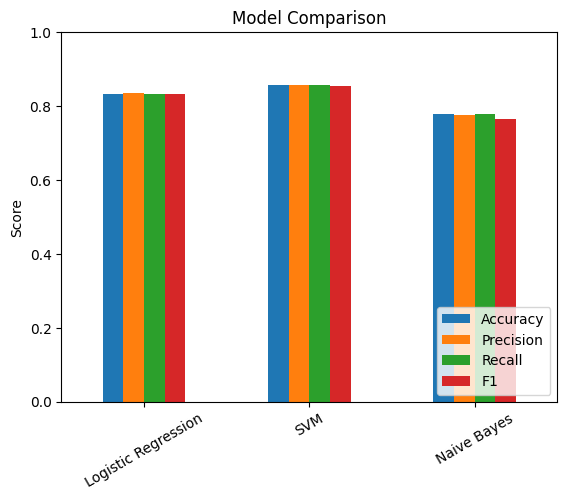

In [14]:
# =========================================================
# 9. VISUALIZE METRICS
# =========================================================

metrics_df.plot(kind="bar")
plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=30)
plt.legend(loc="lower right")
plt.show()

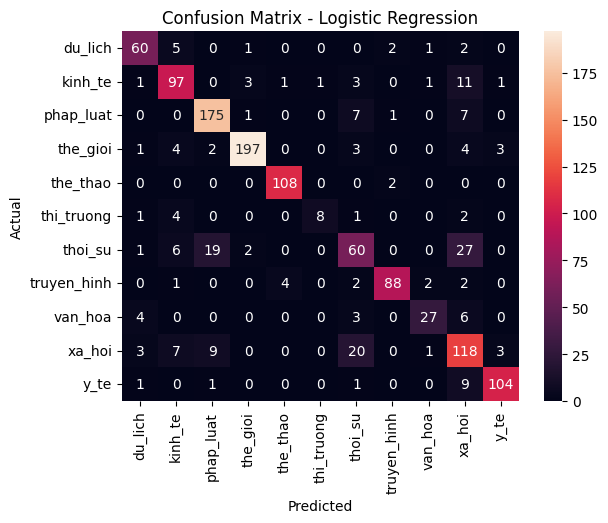

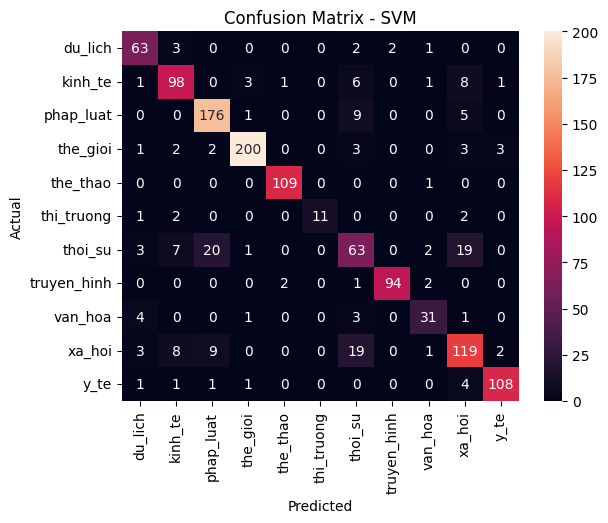

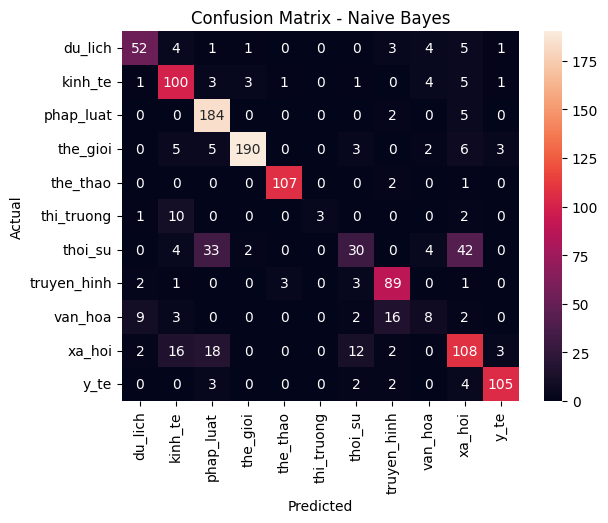

In [16]:
# =========================================================
# 10. CONFUSION MATRICES (ALL MODELS)
# =========================================================

for name, cm in conf_matrices.items():

    plt.figure()
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [18]:
import joblib
import os

SAVE_DIR = "/content/drive/MyDrive/nlp_project/models"
os.makedirs(SAVE_DIR, exist_ok=True)

trained_pipelines = {}

for name, clf in models.items():

    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1,2))),
        ("clf", clf)
    ])

    pipeline.fit(X_train, y_train)

    # lưu model
    model_path = os.path.join(SAVE_DIR, f"{name}.pkl")
    joblib.dump(pipeline, model_path)

    trained_pipelines[name] = pipeline

# lưu label encoder
joblib.dump(label_encoder, os.path.join(SAVE_DIR, "label_encoder.pkl"))

print("All models saved!")

All models saved!


In [19]:
metrics_df.to_csv("/content/drive/MyDrive/nlp_project/reports/model_results.csv", index=True)

In [23]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()



new_article = """
Trong những ngày gần đây giá xăng tăng lên quá cao so với ngày thường cho nên tôi không thể đi đâu chơi ngày 30/4.
"""

new_article = preprocess_text(new_article)

print("\n===== PREDICTION ON NEW ARTICLE =====")

for name, model in trained_pipelines.items():

    pred = model.predict([new_article])
    label = label_encoder.inverse_transform(pred)[0]

    print(f"{name}: {label}")


===== PREDICTION ON NEW ARTICLE =====
Logistic Regression: kinh_te
SVM: the_gioi
Naive Bayes: kinh_te


In [22]:
best_model_name = metrics_df["F1"].idxmax()

print("Best model:", best_model_name)

best_model = trained_pipelines[best_model_name]

Best model: SVM


In [25]:
# =========================================================
# 1. LOAD MODEL
# =========================================================
svm_model = joblib.load("/content/drive/MyDrive/nlp_project/models/SVM.pkl")
label_encoder = joblib.load("/content/drive/MyDrive/nlp_project/models/label_encoder.pkl")

print("SVM model loaded!")

# =========================================================
# 2. PREPROCESS FUNCTION (PHẢI GIỐNG LÚC TRAIN)
# =========================================================

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

# =========================================================
# 3. INPUT NEW ARTICLE
# =========================================================

new_article = """
Trong những ngày gần đây giá xăng tăng lên quá cao so với ngày thường cho nên tôi không thể đi đâu chơi ngày 30/4.
"""

# =========================================================
# 4. PREPROCESS
# =========================================================

processed_text = preprocess_text(new_article)

# =========================================================
# 5. PREDICT
# =========================================================

prediction = svm_model.predict([processed_text])

# decode label
predicted_label = label_encoder.inverse_transform(prediction)[0]

# =========================================================
# 6. RESULT
# =========================================================

print("\n===== PREDICTION RESULT =====")
print("Text:", new_article)
print("Predicted Label:", predicted_label)

SVM model loaded!

===== PREDICTION RESULT =====
Text: 
Trong những ngày gần đây giá xăng tăng lên quá cao so với ngày thường cho nên tôi không thể đi đâu chơi ngày 30/4.

Predicted Label: the_gioi
